# Cross-Fold Validation and Model Optimization

This notebook builds on the response models and uplift models implemented in the model training notebook by:

1. Implementing cross-validation to get more robust performance estimates.
2. Tuning hyperparameters for each model.
3. Comparing the tuned models' performance against each other and against the untuned models.

**Cross-Validation Strategy**: 5-fold stratified cross-validation, preserving treatment/control and conversion balance in each fold.

Each of the 6 models will be tuned separately using the same hyperparameter search space for each algorithm type. This facilitates analysis of whether different model architectures favor different hyperparameter settings. As in the model training phase, I will use the Qini coefficient as the metric because I'm optimizing for uplift.

In [75]:
%pip install pandas
%pip install numpy
%pip install scikit-learn
%pip install lightgbm
%load_ext autoreload
%autoreload 2

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
import joblib
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
# For efficiency, I am suppressing the feature name warnings that arise during the running of the LightGBM models. These warnings are cosmetic
# and do not affect the results. They also only arise with respect to the LightGBM models, not the Logistic Regression models, so suppressing
# them is preferable to adding additional dataframe conversion logic into my cross-validation functions
import warnings
warnings.filterwarnings("ignore")

# Necessary for handling the import of the evaluation metrics
import sys
sys.path.append("..")
from evaluation_metrics.calculate_qini import calculate_qini
from evaluation_metrics.display_uplift_metrics import display_uplift_metrics
from optimization_methods.cv_response_model import cv_response_model
from optimization_methods.cv_s_learner import cv_s_learner
from optimization_methods.cv_t_learner import cv_t_learner
from optimization_methods.hyperparameter_search import hyperparameter_search

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load the train/test split from the model training phase
split_data = joblib.load("../models/train_test_split.joblib")
X_train_processed = split_data["X_train_processed"]
X_test_processed = split_data["X_test_processed"]
y_train = split_data["y_train"]
y_test = split_data["y_test"]
treatment_train = split_data["treatment_train"]
treatment_test = split_data["treatment_test"]
feature_names = split_data["feature_names"]

# My cross-validation functions use NumPy indexing. When data is saved and reloaded using Joblib, sometimes it is automatically converted
# to a NumPy array but sometimes it gets preserved as a series. The below code handles this by extracting the underlying NumPy array if 
# the data is a series
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test
treatment_train_arr = treatment_train.values if hasattr(treatment_train, "values") else treatment_train
treatment_test_arr = treatment_test.values if hasattr(treatment_test, "values") else treatment_test

# Load untuned scores for comparison
untuned_results = joblib.load("../models/untuned_scores.joblib")

print(f"Loaded training set: {len(X_train_processed)} samples")
print(f"Loaded test set: {len(X_test_processed)} samples")
print(f"Features: {feature_names}")

Loaded training set: 34090 samples
Loaded test set: 8523 samples
Features: ['zip_code_Suburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web', 'recency', 'history', 'mens', 'womens', 'newbie']


# Initial Cross-Fold Validation Analysis

Before tuning, I will perform an initial cross-validation analysis of the untuned models. To do so, I will build default Logistic Regression and LightGBM models and test each with a cross-validation function. This will provide a more complete picture of the uplift each of these models provides and will also allow me to confirm my cross-validation functions are working correctly. I expect the Qini coefficients to be similar to those observed during my initial implementation and analysis of my models.


In [77]:
print("Verifying CV framework with default hyperparameters...\n")

# Response Model (LogReg)
lr_default = LogisticRegression(random_state = RANDOM_STATE, max_iter = 1000, class_weight = "balanced")
response_lr_cv = cv_response_model(lr_default, X_train_processed, y_train_arr, treatment_train_arr)
print(f"Response (LogReg) - CV Qini: {response_lr_cv.mean():.2f} (+/- {response_lr_cv.std():.2f})")

# S-Learner (LogReg)
s_learner_lr_cv = cv_s_learner(lr_default, X_train_processed, y_train_arr, treatment_train_arr)
print(f"S-Learner (LogReg) - CV Qini: {s_learner_lr_cv.mean():.2f} (+/- {s_learner_lr_cv.std():.2f})")

# T-Learner (LogReg)
t_learner_lr_cv = cv_t_learner(lr_default, X_train_processed, y_train_arr, treatment_train_arr)
print(f"T-Learner (LogReg) - CV Qini: {t_learner_lr_cv.mean():.2f} (+/- {t_learner_lr_cv.std():.2f})")

print("\n")

# LightGBM models
lgbm_default = LGBMClassifier(random_state = RANDOM_STATE, class_weight = "balanced", verbose = -1)

response_lgbm_cv = cv_response_model(lgbm_default, X_train_processed, y_train_arr, treatment_train_arr)
print(f"Response (LGBM) - CV Qini: {response_lgbm_cv.mean():.2f} (+/- {response_lgbm_cv.std():.2f})")

s_learner_lgbm_cv = cv_s_learner(lgbm_default, X_train_processed, y_train_arr, treatment_train_arr)
print(f"S-Learner (LGBM) - CV Qini: {s_learner_lgbm_cv.mean():.2f} (+/- {s_learner_lgbm_cv.std():.2f})")

t_learner_lgbm_cv = cv_t_learner(lgbm_default, X_train_processed, y_train_arr, treatment_train_arr)
print(f"T-Learner (LGBM) - CV Qini: {t_learner_lgbm_cv.mean():.2f} (+/- {t_learner_lgbm_cv.std():.2f})")

Verifying CV framework with default hyperparameters...

Response (LogReg) - CV Qini: -0.01 (+/- 2.50)
S-Learner (LogReg) - CV Qini: -0.68 (+/- 2.44)
T-Learner (LogReg) - CV Qini: -1.21 (+/- 1.84)


Response (LGBM) - CV Qini: 0.34 (+/- 1.51)
S-Learner (LGBM) - CV Qini: -0.72 (+/- 0.89)
T-Learner (LGBM) - CV Qini: -0.13 (+/- 1.81)


Some of the Qini coefficients are similar to the results from my initial analysis (e.g., the S-Learners achieved Qinis of -0.68 and -0.72, which are similar to the -1.2 and -1.3 values achieved by the initial S-Learners). However, some are pretty far off. For example, in my initial analysis, the Logistic Regression response model had a Qini of 5.5, but here it has a Qini of -0.01. Similarly, the LightGBM T-Learner had a Qini of 3.5 in the initial analysis, but scored -0.13 here. 

These are substantial differences and suggest that the results of my initial analysis may have been optimistically biased by the particular random split used for that evaluation. The high standard deviations indicate that Qini can vary dramatically depending on which customers end up in the validation set. This is not surprising given the low conversion rate in this dataset, and it demonstrates why cross-validation is so valuable here. Averaging across five validation sets provides a more robust and accurate estimate of the model's uplift than evaluating on a single split.

# Hyperparameter Tuning: Logistic Regression

For Logistic Regression, the main hyperparameters to tune are:
- **C**: Inverse regularization strength (smaller = more regularization).
- **penalty**: Type of regularization (L1 or L2).

With only 18 combinations, an exhaustive grid search is possible.

In [78]:
lr_param_grid = {
    "C": [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    "penalty": ["l1", "l2"],
    # Use saga solver because it provides the most robust support for both L1 and L2 regularization and class_weight = balanced
    "solver": ["saga"],
    "max_iter": [2000],
    "class_weight": ["balanced"],
    "random_state": [RANDOM_STATE]
}

### Hyperparameter Tuning: Response Model (Logistic Regression)

In [79]:
print("Tuning Response Model (Logistic Regression)...\n")

response_lr_results = hyperparameter_search(
    model_class = LogisticRegression,
    param_grid = lr_param_grid,
    X = X_train_processed,
    y = y_train_arr,
    treatment = treatment_train_arr,
    cv_func = cv_response_model,
    n_splits = 5
)

print("\nTop 5 parameter combinations:")
response_lr_results["results_df"].head()

Tuning Response Model (Logistic Regression)...

Testing 18 parameter combinations...
  Completed 10/18, best Qini so far: 0.6652

Best parameters: {'C': 0.001, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 2000, 'class_weight': 'balanced', 'random_state': 42}
Best mean Qini: 0.6652

Top 5 parameter combinations:


,C,penalty,solver,max_iter,class_weight,random_state,mean_qini,std_qini
0,0.001,l1,saga,2000,balanced,42,0.665168,3.130875
2,0.010,l1,saga,2000,balanced,42,0.491451,2.799856
1,0.001,l2,saga,2000,balanced,42,0.413580,2.758460
4,0.100,l1,saga,2000,balanced,42,0.367915,2.699696
3,0.010,l2,saga,2000,balanced,42,0.358058,2.682880


### Hyperparamter Tuning: S-Learner (Logistic Regression)

In [80]:
print("Tuning S-Learner (Logistic Regression)...\n")

s_learner_lr_results = hyperparameter_search(
    model_class = LogisticRegression,
    param_grid = lr_param_grid,
    X = X_train_processed,
    y = y_train_arr,
    treatment = treatment_train_arr,
    cv_func = cv_s_learner,
    n_splits = 5
)

print("\nTop 5 parameter combinations:")
s_learner_lr_results["results_df"].head()

Tuning S-Learner (Logistic Regression)...

Testing 18 parameter combinations...
  Completed 10/18, best Qini so far: 0.1831

Best parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 2000, 'class_weight': 'balanced', 'random_state': 42}
Best mean Qini: 0.1831

Top 5 parameter combinations:


,C,penalty,solver,max_iter,class_weight,random_state,mean_qini,std_qini
2,0.010,l1,saga,2000,balanced,42,0.183145,1.667723
1,0.001,l2,saga,2000,balanced,42,0.172101,1.793267
4,0.100,l1,saga,2000,balanced,42,0.115498,1.785162
3,0.010,l2,saga,2000,balanced,42,-0.010083,1.973601
5,0.100,l2,saga,2000,balanced,42,-0.016690,1.989525


### Hyperparameter Tuning: T-Learner (Logistic Regression)

In [81]:
print("Tuning T-Learner (Logistic Regression)...\n")

t_learner_lr_results = hyperparameter_search(
    model_class = LogisticRegression,
    param_grid = lr_param_grid,
    X = X_train_processed,
    y = y_train_arr,
    treatment = treatment_train_arr,
    cv_func = cv_t_learner,
    n_splits = 5
)

print("\nTop 5 parameter combinations:")
t_learner_lr_results["results_df"].head()

Tuning T-Learner (Logistic Regression)...

Testing 18 parameter combinations...
  Completed 10/18, best Qini so far: -0.2238

Best parameters: {'C': 0.001, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 2000, 'class_weight': 'balanced', 'random_state': 42}
Best mean Qini: -0.2238

Top 5 parameter combinations:


,C,penalty,solver,max_iter,class_weight,random_state,mean_qini,std_qini
0,0.001,l1,saga,2000,balanced,42,-0.223793,2.860261
1,0.001,l2,saga,2000,balanced,42,-0.870310,2.746991
5,0.100,l2,saga,2000,balanced,42,-0.876177,2.662960
16,100.000,l1,saga,2000,balanced,42,-0.876482,2.660679
17,100.000,l2,saga,2000,balanced,42,-0.878382,2.657985


### Logistic Regression Tuning Summary

In [82]:
print("Logistic Regression Tuning Summary")
print("=" * 60)
print(f"\nResponse Model:")
print(f"  Best Qini: {response_lr_results['best_score']:.4f}")
print(f"  Best C: {response_lr_results['best_params']['C']}")
print(f"  Best penalty: {response_lr_results['best_params']['penalty']}")

print(f"\nS-Learner:")
print(f"  Best Qini: {s_learner_lr_results['best_score']:.4f}")
print(f"  Best C: {s_learner_lr_results['best_params']['C']}")
print(f"  Best penalty: {s_learner_lr_results['best_params']['penalty']}")

print(f"\nT-Learner:")
print(f"  Best Qini: {t_learner_lr_results['best_score']:.4f}")
print(f"  Best C: {t_learner_lr_results['best_params']['C']}")
print(f"  Best penalty: {t_learner_lr_results['best_params']['penalty']}")

Logistic Regression Tuning Summary

Response Model:
  Best Qini: 0.6652
  Best C: 0.001
  Best penalty: l1

S-Learner:
  Best Qini: 0.1831
  Best C: 0.01
  Best penalty: l1

T-Learner:
  Best Qini: -0.2238
  Best C: 0.001
  Best penalty: l1


# Hyperparameter Tuning: LightGBM

Like XGBoost, one advantage of LightGBM is its wide array of hyperparameters for tuning. This diversity of hyperparameters offers numerous opportunities for optimization, but it comes at a cost: the more hyperparameters that are tuned, the longer a full search takes. Given the number of hyperparameters that can be tuned, the number of possible combinations of hyperparameters can grow exponentially, eventually making it infeasible to test all combinations.

To address this, when tuning the LightGBM models, I will specify n_iter = 100. This tells the hyperparameter_search function to test 100 different hyperparameter combinations.

The hyperparameters to be tested for the LightGBM models are as follows:
- **num_leaves**: Main parameter controlling model complexity.
- **max_depth**: Limits tree depth to prevent overfitting.
- **learning_rate**: Step size for gradient descent.
- **n_estimators**: Number of boosting rounds.
- **reg_alpha / reg_lambda**: L1/L2 regularization.
- **min_child_samples**: Minimum samples per leaf (prevents overfitting).

In [83]:
lgbm_param_grid = {
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [3, 5, 7, 10, -1],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 300, 500],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0, 0.01, 0.1, 1],
    "min_child_samples": [5, 10, 20, 50],
    "class_weight": ["balanced"],
    "verbose": [-1],
    "random_state": [RANDOM_STATE]
}

total_combinations = 4 * 5 * 4 * 4 * 4 * 4 * 4
print(f"LightGBM parameter grid: {total_combinations:,} total combinations")
print(f"Using randomized search with n_iter = 100")

LightGBM parameter grid: 20,480 total combinations
Using randomized search with n_iter = 100


### Hyperparameter Tuning: Response Model (LightGBM)

In [84]:
print("Tuning Response Model (LightGBM)...\n")

response_lgbm_results = hyperparameter_search(
    model_class = LGBMClassifier,
    param_grid = lgbm_param_grid,
    X = X_train_processed,
    y = y_train_arr,
    treatment = treatment_train_arr,
    cv_func = cv_response_model,
    n_iter = 100, # Randomized search with 100 iterations to limit runtime
    n_splits = 5
)

print("\nTop 5 parameter combinations:")
response_lgbm_results["results_df"].head()

Tuning Response Model (LightGBM)...

Testing 100 parameter combinations...
  Completed 10/100, best Qini so far: 1.1437
  Completed 20/100, best Qini so far: 1.1437
  Completed 30/100, best Qini so far: 1.1437
  Completed 40/100, best Qini so far: 1.1437
  Completed 50/100, best Qini so far: 1.1560
  Completed 60/100, best Qini so far: 1.2843
  Completed 70/100, best Qini so far: 1.2843
  Completed 80/100, best Qini so far: 1.4981
  Completed 90/100, best Qini so far: 1.4981
  Completed 100/100, best Qini so far: 1.4981

Best parameters: {'num_leaves': 63, 'max_depth': 7, 'learning_rate': 0.01, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 1, 'min_child_samples': 20, 'class_weight': 'balanced', 'verbose': -1, 'random_state': 42}
Best mean Qini: 1.4981

Top 5 parameter combinations:


,num_leaves,max_depth,learning_rate,n_estimators,reg_alpha,reg_lambda,min_child_samples,class_weight,verbose,random_state,mean_qini,std_qini
76,63,7,0.01,100,1.00,1.00,20,balanced,-1,42,1.498126,1.126739
50,127,5,0.01,100,1.00,1.00,5,balanced,-1,42,1.284319,1.410315
85,63,3,0.01,100,0.01,0.01,10,balanced,-1,42,1.172219,2.093009
40,63,3,0.01,100,0.00,0.10,10,balanced,-1,42,1.155955,2.215781
1,31,3,0.01,100,0.10,0.10,5,balanced,-1,42,1.143719,2.170141


### Hyperparameter Tuning: S-Learner (LightGBM)

In [85]:
print("Tuning S-Learner (LightGBM)...\n")

s_learner_lgbm_results = hyperparameter_search(
    model_class = LGBMClassifier,
    param_grid = lgbm_param_grid,
    X = X_train_processed,
    y = y_train_arr,
    treatment = treatment_train_arr,
    cv_func = cv_s_learner,
    n_iter = 100,
    n_splits = 5
)

print("\nTop 5 parameter combinations:")
s_learner_lgbm_results["results_df"].head()

Tuning S-Learner (LightGBM)...

Testing 100 parameter combinations...
  Completed 10/100, best Qini so far: 0.5765
  Completed 20/100, best Qini so far: 0.5845
  Completed 30/100, best Qini so far: 0.5845
  Completed 40/100, best Qini so far: 0.5845
  Completed 50/100, best Qini so far: 0.5845
  Completed 60/100, best Qini so far: 0.5845
  Completed 70/100, best Qini so far: 0.5845
  Completed 80/100, best Qini so far: 0.5845
  Completed 90/100, best Qini so far: 0.5845
  Completed 100/100, best Qini so far: 0.5845

Best parameters: {'num_leaves': 15, 'max_depth': 5, 'learning_rate': 0.01, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 0.01, 'min_child_samples': 10, 'class_weight': 'balanced', 'verbose': -1, 'random_state': 42}
Best mean Qini: 0.5845

Top 5 parameter combinations:


,num_leaves,max_depth,learning_rate,n_estimators,reg_alpha,reg_lambda,min_child_samples,class_weight,verbose,random_state,mean_qini,std_qini
18,15,5,0.01,100,1.00,0.01,10,balanced,-1,42,0.584475,0.893462
7,15,7,0.01,300,0.00,1.00,10,balanced,-1,42,0.576540,1.147380
42,63,-1,0.20,200,1.00,0.10,10,balanced,-1,42,0.559247,1.372927
91,31,-1,0.10,300,0.01,0.00,5,balanced,-1,42,0.557474,1.440510
88,127,-1,0.20,500,0.00,0.10,20,balanced,-1,42,0.553517,1.065058


### Hyperparameter Tuning: T-Learner (LightGBM)

In [86]:
print("Tuning T-Learner (LightGBM)...\n")

t_learner_lgbm_results = hyperparameter_search(
    model_class = LGBMClassifier,
    param_grid = lgbm_param_grid,
    X = X_train_processed,
    y = y_train_arr,
    treatment = treatment_train_arr,
    cv_func = cv_t_learner,
    n_iter = 100,
    n_splits = 5
)

print("\nTop 5 parameter combinations:")
t_learner_lgbm_results["results_df"].head()

Tuning T-Learner (LightGBM)...

Testing 100 parameter combinations...
  Completed 10/100, best Qini so far: 0.8652
  Completed 20/100, best Qini so far: 0.8652
  Completed 30/100, best Qini so far: 0.8652
  Completed 40/100, best Qini so far: 0.8652
  Completed 50/100, best Qini so far: 0.8960
  Completed 60/100, best Qini so far: 0.8960
  Completed 70/100, best Qini so far: 0.8960
  Completed 80/100, best Qini so far: 0.8960
  Completed 90/100, best Qini so far: 0.8960
  Completed 100/100, best Qini so far: 0.8960

Best parameters: {'num_leaves': 63, 'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 0.1, 'min_child_samples': 10, 'class_weight': 'balanced', 'verbose': -1, 'random_state': 42}
Best mean Qini: 0.8960

Top 5 parameter combinations:


,num_leaves,max_depth,learning_rate,n_estimators,reg_alpha,reg_lambda,min_child_samples,class_weight,verbose,random_state,mean_qini,std_qini
40,63,3,0.01,100,0.00,0.10,10,balanced,-1,42,0.896034,0.666464
85,63,3,0.01,100,0.01,0.01,10,balanced,-1,42,0.888743,0.647480
83,127,3,0.01,200,1.00,0.10,5,balanced,-1,42,0.871610,1.072168
1,31,3,0.01,100,0.10,0.10,5,balanced,-1,42,0.865195,0.685065
61,127,7,0.01,300,0.01,1.00,50,balanced,-1,42,0.761878,1.615724


### LightGBM Tuning Summary

In [87]:
print("LightGBM Tuning Summary")
print("=" * 60)

# Print the best Qini and best parameters for each LightGBM model
print(f"\nResponse Model:")
print(f"  Best Qini: {response_lgbm_results['best_score']:.4f}")

for k, v in response_lgbm_results["best_params"].items():
    if k not in ["class_weight", "verbose", "random_state"]:
        print(f"  {k}: {v}")

print(f"\nS-Learner:")
print(f"  Best Qini: {s_learner_lgbm_results['best_score']:.4f}")

for k, v in s_learner_lgbm_results["best_params"].items():
    if k not in ["class_weight", "verbose", "random_state"]:
        print(f"  {k}: {v}")

print(f"\nT-Learner:")
print(f"  Best Qini: {t_learner_lgbm_results['best_score']:.4f}")

for k, v in t_learner_lgbm_results["best_params"].items():
    if k not in ["class_weight", "verbose", "random_state"]:
        print(f"  {k}: {v}")

LightGBM Tuning Summary

Response Model:
  Best Qini: 1.4981
  num_leaves: 63
  max_depth: 7
  learning_rate: 0.01
  n_estimators: 100
  reg_alpha: 1
  reg_lambda: 1
  min_child_samples: 20

S-Learner:
  Best Qini: 0.5845
  num_leaves: 15
  max_depth: 5
  learning_rate: 0.01
  n_estimators: 100
  reg_alpha: 1
  reg_lambda: 0.01
  min_child_samples: 10

T-Learner:
  Best Qini: 0.8960
  num_leaves: 63
  max_depth: 3
  learning_rate: 0.01
  n_estimators: 100
  reg_alpha: 0
  reg_lambda: 0.1
  min_child_samples: 10


# Training and Evaluation of Optimized Models

In [88]:
# Store all tuned results for final comparison
tuned_results = {}

# Random baseline (no tuning needed)
tuned_results["Random Targeting"] = untuned_results["Random"]

### Model Training and Testing: Response Models

In [89]:
treatment_mask = treatment_train_arr == 1

# Response Model (LogReg)
lr_response_tuned = LogisticRegression(**response_lr_results["best_params"])
lr_response_tuned.fit(X_train_processed[treatment_mask], y_train_arr[treatment_mask])
tuned_results["Response (LogReg)"] = lr_response_tuned.predict_proba(X_test_processed)[:, 1]

# Response Model (LightGBM)
lgbm_response_tuned = LGBMClassifier(**response_lgbm_results["best_params"])
lgbm_response_tuned.fit(X_train_processed[treatment_mask], y_train_arr[treatment_mask])
tuned_results["Response (LGBM)"] = lgbm_response_tuned.predict_proba(X_test_processed)[:, 1]

print("Response models trained with tuned hyperparameters.")

Response models trained with tuned hyperparameters.


### Model Training and Testing: S-Learners

In [90]:
X_train_with_treatment = np.column_stack([X_train_processed, treatment_train_arr])
X_test_treated = np.column_stack([X_test_processed, np.ones(len(X_test_processed))])
X_test_control = np.column_stack([X_test_processed, np.zeros(len(X_test_processed))])

# S-Learner (LogReg)
lr_s_learner_tuned = LogisticRegression(**s_learner_lr_results["best_params"])
lr_s_learner_tuned.fit(X_train_with_treatment, y_train_arr)
tuned_results["S-Learner (LogReg)"] = (
    lr_s_learner_tuned.predict_proba(X_test_treated)[:, 1] - 
    lr_s_learner_tuned.predict_proba(X_test_control)[:, 1]
)

# S-Learner (LightGBM)
lgbm_s_learner_tuned = LGBMClassifier(**s_learner_lgbm_results["best_params"])
lgbm_s_learner_tuned.fit(X_train_with_treatment, y_train_arr)
tuned_results["S-Learner (LGBM)"] = (
    lgbm_s_learner_tuned.predict_proba(X_test_treated)[:, 1] - 
    lgbm_s_learner_tuned.predict_proba(X_test_control)[:, 1]
)

print("S-Learner models trained with tuned hyperparameters.")

S-Learner models trained with tuned hyperparameters.


### Model Training and Testing: T-Learners

In [91]:
treatment_mask = treatment_train_arr == 1
control_mask = treatment_train_arr == 0

# T-Learner (LogReg)
lr_t_treatment = LogisticRegression(**t_learner_lr_results["best_params"])
lr_t_control = LogisticRegression(**t_learner_lr_results["best_params"])
lr_t_treatment.fit(X_train_processed[treatment_mask], y_train_arr[treatment_mask])
lr_t_control.fit(X_train_processed[control_mask], y_train_arr[control_mask])
tuned_results["T-Learner (LogReg)"] = (
    lr_t_treatment.predict_proba(X_test_processed)[:, 1] - 
    lr_t_control.predict_proba(X_test_processed)[:, 1]
)

# T-Learner (LightGBM)
lgbm_t_treatment = LGBMClassifier(**t_learner_lgbm_results["best_params"])
lgbm_t_control = LGBMClassifier(**t_learner_lgbm_results["best_params"])
lgbm_t_treatment.fit(X_train_processed[treatment_mask], y_train_arr[treatment_mask])
lgbm_t_control.fit(X_train_processed[control_mask], y_train_arr[control_mask])
tuned_results["T-Learner (LGBM)"] = (
    lgbm_t_treatment.predict_proba(X_test_processed)[:, 1] - 
    lgbm_t_control.predict_proba(X_test_processed)[:, 1]
)

print("T-Learner models trained with tuned hyperparameters.")

T-Learner models trained with tuned hyperparameters.


Tuned Models - Uplift Metrics

Random Targeting:
  AUUC: 11.74
  Qini: -3.25

Response (LogReg):
  AUUC: 22.23
  Qini: 7.23

Response (LGBM):
  AUUC: 20.10
  Qini: 5.11

S-Learner (LogReg):
  AUUC: 15.51
  Qini: 0.52

S-Learner (LGBM):
  AUUC: 13.39
  Qini: -1.61

T-Learner (LogReg):
  AUUC: 9.26
  Qini: -5.74

T-Learner (LGBM):
  AUUC: 13.88
  Qini: -1.11


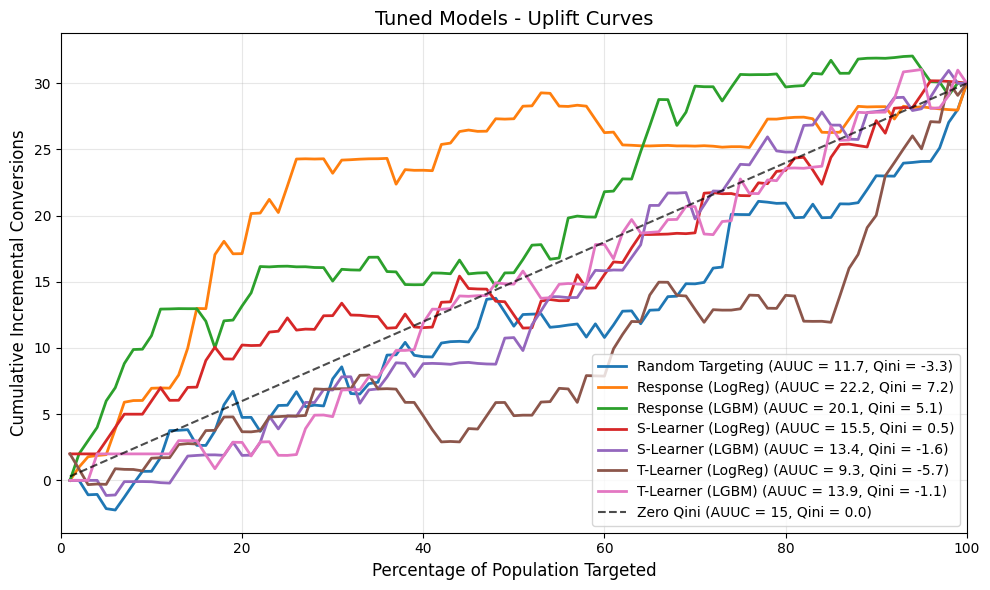

In [92]:
display_uplift_metrics(tuned_results, "Tuned Models", 
                       pd.Series(y_test_arr), pd.Series(treatment_test_arr))

# Analysis and Conclusions

The table below compares model performance before and after hyperparameter tuning.

In [93]:
print(tuned_results.keys())
models = [
        "Response (LogReg)", "Response (LGBM)",
        "S-Learner (LogReg)", "S-Learner (LGBM)",
        "T-Learner (LogReg)", "T-Learner (LGBM)"
]

comparison_data = {
    "Model": models,
    "Untuned Qini": [
        calculate_qini(y_test_arr, treatment_test_arr, untuned_results[model]) for model in models
    ],
    "Tuned Qini": [
        calculate_qini(y_test_arr, treatment_test_arr, tuned_results[model]) for model in models
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df["Improvement"] = comparison_df["Tuned Qini"] - comparison_df["Untuned Qini"]
comparison_df["% Change"] = (comparison_df["Improvement"] / comparison_df["Untuned Qini"].abs() * 100).round(1)

print("Performance Comparison: Untuned vs Tuned")
print("=" * 70)

comparison_df

dict_keys(['Random Targeting', 'Response (LogReg)', 'Response (LGBM)', 'S-Learner (LogReg)', 'S-Learner (LGBM)', 'T-Learner (LogReg)', 'T-Learner (LGBM)'])
Performance Comparison: Untuned vs Tuned


,Model,Untuned Qini,Tuned Qini,Improvement,% Change
0,Response (LogReg),5.472815,7.229879,1.757064,32.1
1,Response (LGBM),2.638720,5.105110,2.466390,93.5
2,S-Learner (LogReg),-1.245050,0.518467,1.763517,141.6
3,S-Learner (LGBM),-1.336625,-1.605433,-0.268808,-20.1
4,T-Learner (LogReg),-2.541787,-5.740464,-3.198677,-125.8
5,T-Learner (LGBM),3.509524,-1.110704,-4.620228,-131.6


These are surprising results. After tuning, both response models substantially outperformed the uplift models by even wider margins than the initial implementations. Moreover, only one of the uplift models even showed a positive change after tuning. The other three performed worse than their initial implementations. The LightGBM T-Learner even performed worse than random targeting.

These results suggest that the features in this dataset may not effectively differentiate between "persuadables" (customers who would not buy without treatment) and "sure things" (customers who would buy regardless). As a result, response models are sufficient to capture most of the signal, whereas uplift models fall short.

Furthermore, the uplift models are at a distinct disadvantage [1]. While the response models only predict one thing, P(conversion), the uplift models estimate the difference between two predictions. This compounds the possibility for error. This is especially true where, as here, the uplift models are asked to predict rare outcomes.

Consider, for example, the worst-performing model: the Logistic Regression T-Learner. It trains separate treatment and control models, each with ~17,000 customers and an approximately 1% conversion rate, yielding ~170 conversions per model. Given the tiny conversion rate, the models may be simply learning noise, and when subtracted from each other, the result is even noisier. This is evident from the heavy regularization this T-Learner selected via the tuning process (C = 0.001). This suggests that the tuning process recognized the noise and attempted to constrain it via regularization, but this was not sufficient to preserve the algorithm's performance.

Others have reported similar findings when working with this dataset. For example, when studying the effects of uplift models on the Hillstrom dataset, Nyberg and Klami found that "on the smallest dataset, Hillstrom, all mAUUC-metrics are essentially zero and slightly below the baselines." [2]. While this study combined undersampling with uplift models, it still supports the conclusion that dataset size and imbalanced outcomes can affect uplift model performance.

These results disprove my hypothesis that uplift models would be stronger at predicting persuadability than the response models. In doing so, they validate the importance of cross-fold validation. The LightGBM T-Learner looked promising in its initial implementation, but its performance decreased during cross-fold validation, even after hyperparameter tuning, suggesting that this was due to a favorable train/test split.

**Final Recommendation:** Given these results, my final recommendation for the company would be to use one of the response models to determine whom to target in future campaigns. The results showed that more complexity is not always better. Given the size of the company's dataset, a simple model that predicts who is most likely to buy should be sufficient to capture most of the signal. There is no need to add extra layers of complexity.

Which response model to use depends on the percentage of the company's customer base that it wants to target. The LightGBM response model seems to perform better for low and high percentages, while the Logistic Regression response model performs better between ~18% and ~62%. It also has a higher overall Qini score. It shows a larger advantage over the LightGBM response model in the middle percentages than the LightGBM does at the lower and higher percentages. Given that, the Logistic Regression response model may be the safer choice. However, if the company wants to run a much more targeted campaign aimed at a small percentage of its customers, or a blanket campaign targeting nearly all customers, it may want to consider using the LightGBM response model.

# Sources

[1] Proppe, D. (2017). *Uplift modelling is hard — but worth it*. Medium. https://medium.com/touchpoints-ai/uplift-modelling-is-hard-but-worth-it-37a9e9dc5015.

[2] Nyberg, O. (2023). *Exploring uplift modeling with high class imbalance*. Data Mining and Knowledge Discovery. https://link.springer.com/article/10.1007/s10618-023-00917-9.